In [1]:
# Import libraries
import ast
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
# Load dataset
df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/finalverses.csv", encoding='utf-8-sig')
print("Initial shape:", df.shape)

Initial shape: (34981, 15)


In [ ]:
print("=========================== Dataset Variables ===========================\n")

print(df.columns)

=========================== Dataset Variables ===========================

Index(['verse_id', 'song_id', 'ori_track_name', 'clean_track_name',
       'all_artists', 'primary_artist', 'artist_genres', 'main_genre',
       'explicit', 'section', 'verse', 'language', 'confidence', 'tokens',
       'label'],
      dtype='str')


In [4]:
# Distribution of length of verses (tokens column)
# Parse list-like strings and count the number of tokens in each row
def parse_tokens(value):
    if isinstance(value, (list, tuple, set)):
        return list(value)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple, set)):
                return list(parsed)
        except (ValueError, SyntaxError):
            pass
        return value.split()
    return list(value) if hasattr(value, '__iter__') else [value]
df['verse_length'] = df['tokens'].apply(
    lambda value: len([
        token for token in parse_tokens(value)
        if re.search(r"\w", token)  # keeps only tokens with letters/numbers
    ])
)

print("\n======== Verse Length Distribution ========\n")
print(df['verse_length'].describe())

# Find upper bound for outliers using IQR
Q1 = df['verse_length'].quantile(0.25)
Q3 = df['verse_length'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nUpper bound for outliers: {upper_bound}")


======== Verse Length Distribution ========

count    34981.000000
mean        50.627541
std         43.429872
min          1.000000
25%         27.000000
50%         41.000000
75%         62.000000
max       1291.000000
Name: verse_length, dtype: float64

Upper bound for outliers: 114.5


In [ ]:
# Find upper bound for outliers using IQR
Q1 = df['verse_length'].quantile(0.25)
Q3 = df['verse_length'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nUpper bound for outliers: {upper_bound}")

no_outliers = df[df['verse_length'] <= upper_bound]
no_outliers.to_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/no_outliers.csv", index=False, encoding='utf-8-sig')
print(no_outliers.shape)


Upper bound for outliers: 114.5
(32842, 19)


(32842, 19)


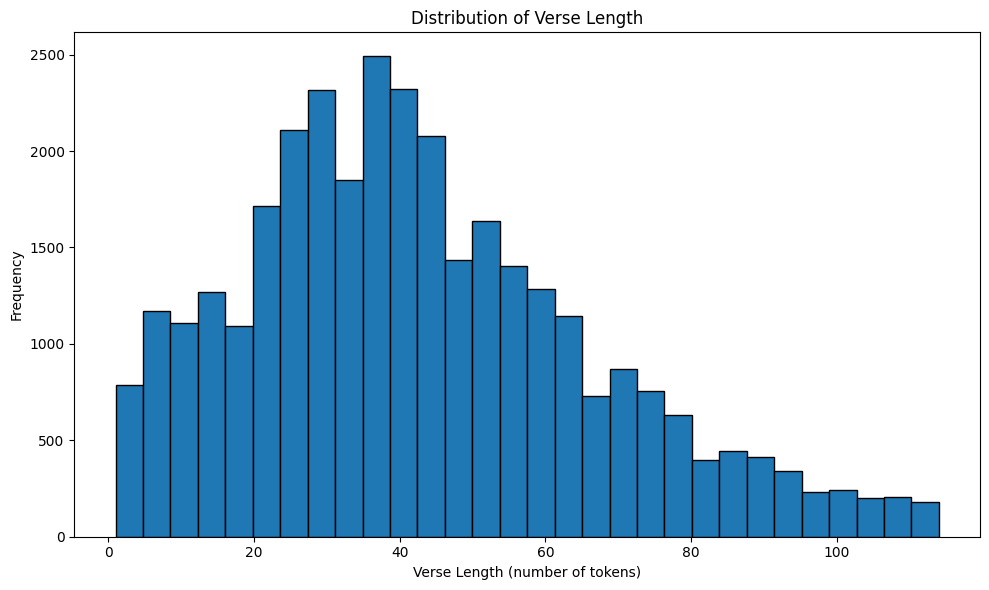

In [ ]:
# Create a new DataFrame below the upper bound
no_outliers = df[df['verse_length'] <= 114]
print(no_outliers.shape)

# Plot distribution of verse length
plt.figure(figsize=(10, 6))
plt.hist(no_outliers['verse_length'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Verse Length')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

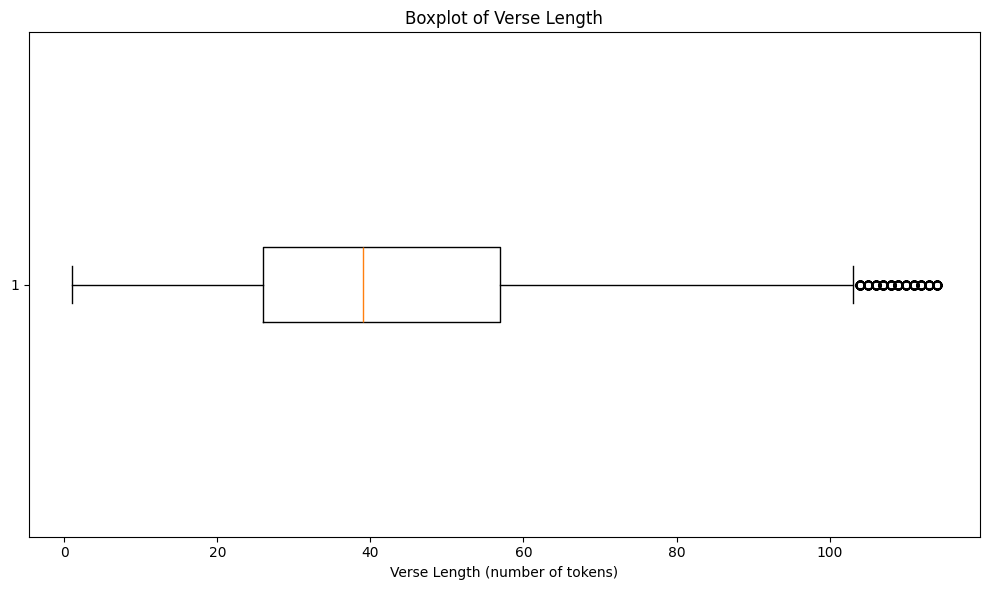

In [ ]:
# Boxplot for verse length
plt.figure(figsize=(10, 6))
plt.boxplot(no_outliers['verse_length'].dropna(), vert=False)
plt.title('Boxplot of Verse Length')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

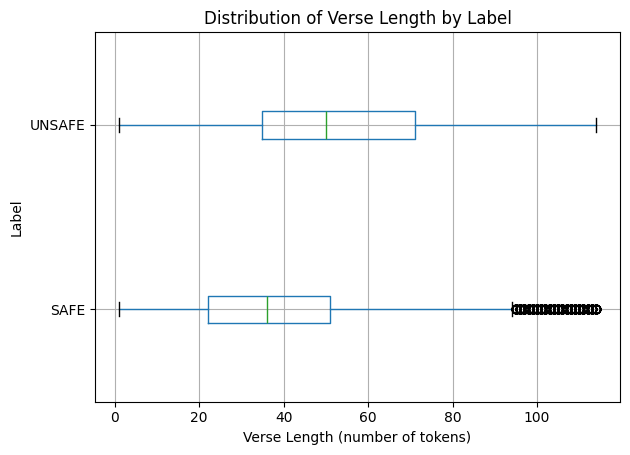

In [ ]:
# Distribution of verse length by label
plt.figure(figsize=(10, 6))
no_outliers.boxplot(column='verse_length', by='label', vert=False)
plt.title('Distribution of Verse Length by Label')
plt.suptitle('')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

In [ ]:
# Generate word cloud for safe and unsafe songs
safe_tokens = df[df['label'].str.upper() == 'SAFE']['tokens'].dropna().apply(parse_tokens)
unsafe_tokens = df[df['label'].str.upper() == 'UNSAFE']['tokens'].dropna().apply(parse_tokens)
safe_text = ' '.join(' '.join(tokens) for tokens in safe_tokens if tokens)
unsafe_text = ' '.join(' '.join(tokens) for tokens in unsafe_tokens if tokens)

if not safe_text or not unsafe_text:
    raise ValueError('No tokens found for safe or unsafe word clouds after filtering.')
safe_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(safe_text)
unsafe_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(unsafe_text)

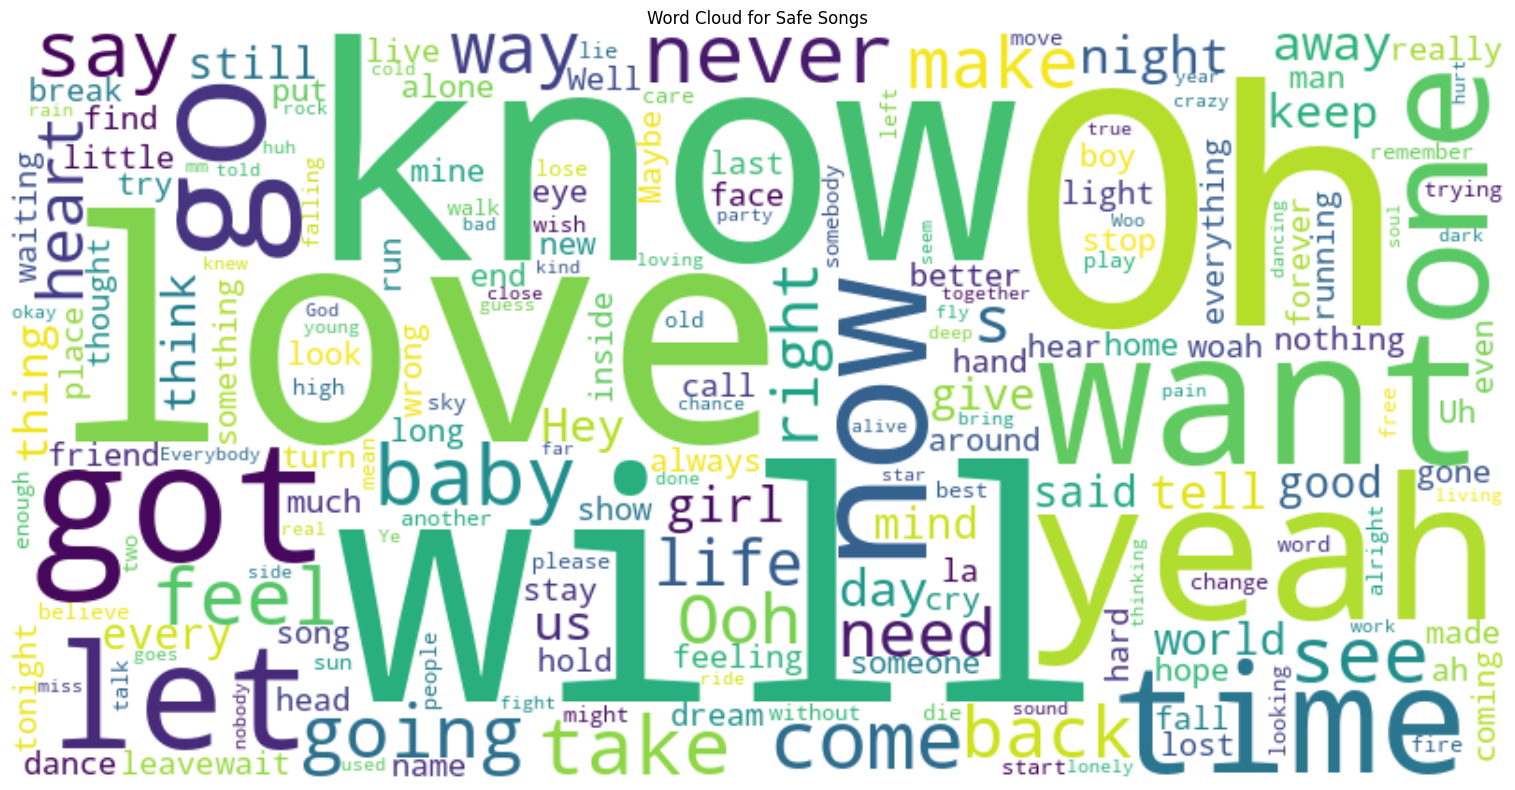

In [ ]:
# Plot word cloud for safe songs
plt.figure(figsize=(16, 8))
plt.imshow(safe_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Safe Songs')
plt.axis('off')
plt.tight_layout()
plt.show()

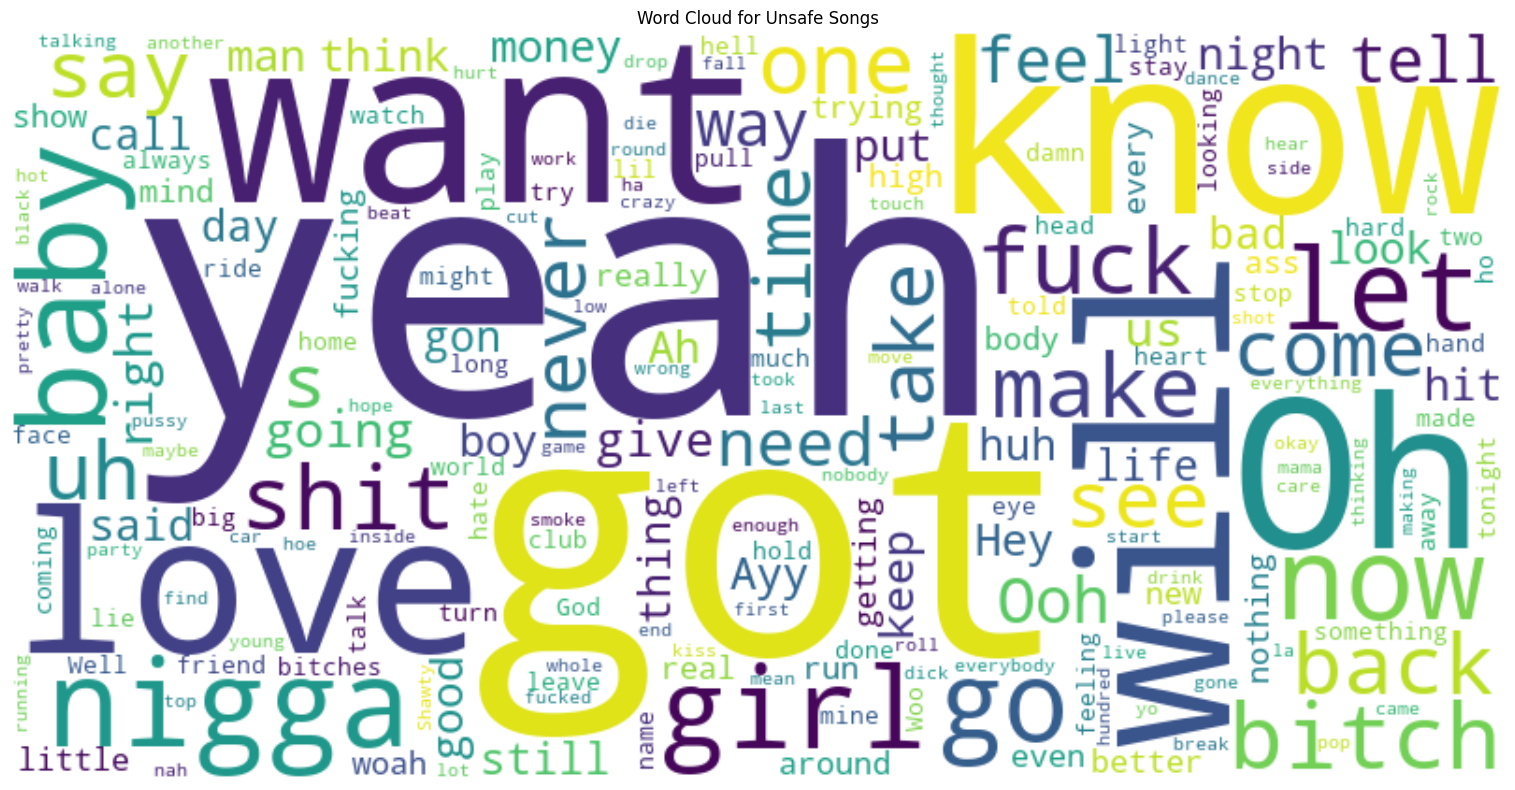

In [ ]:
# Plot word cloud for unsafe songs
plt.figure(figsize=(16, 8))
plt.imshow(unsafe_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Unsafe Songs')
plt.axis('off')
plt.tight_layout()
plt.show()

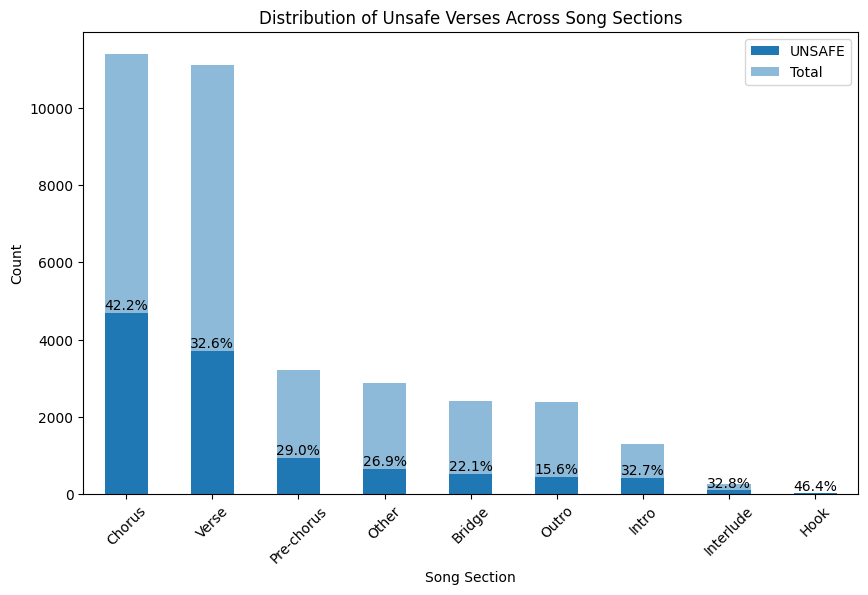

In [3]:
# Visualize distibution of UNSAFE verses and total verses in different sections of the songs
# Print percentage of UNSAFE verses in each section
section_unsafe = df[df['label'] == 'UNSAFE']['section'].value_counts()
section_total = df['section'].value_counts()

plt.figure(figsize=(10, 6))
ax = section_unsafe.plot(kind='bar', label='UNSAFE')
section_total.plot(kind='bar', label='Total', alpha=0.5)
section_percentage = (section_unsafe / section_total) * 100

# Add percentage labels
for i, val in enumerate(section_unsafe):
    section = section_unsafe.index[i]
    pct = section_percentage[section]
    ax.text(i, val, f"{pct:.1f}%", ha='center', va='bottom')

plt.title('Distribution of Unsafe Verses Across Song Sections')
plt.xlabel('Song Section')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.show()